# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [91]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [92]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [93]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [94]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [95]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [96]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [97]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [98]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [99]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [100]:
# cantidad de nulos para users
print(users.isna().sum().sort_values(ascending=False))
print()
print(users.isna().mean().sort_values(ascending=False))

churn_date    3534
city           469
user_id          0
first_name       0
last_name        0
age              0
reg_date         0
plan             0
dtype: int64

churn_date    0.88350
city          0.11725
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
reg_date      0.00000
plan          0.00000
dtype: float64


In [101]:
# cantidad de nulos para usage
print(usage.isna().sum().sort_values(ascending=False))
print()
print(usage.isna().mean().sort_values(ascending=False))

duration    22076
length      17896
date           50
id              0
user_id         0
type            0
dtype: int64

duration    0.55190
length      0.44740
date        0.00125
id          0.00000
user_id     0.00000
type        0.00000
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- En el dataframe de users encontramos valores nulos en las columnas de churn_date(88.35%), city(12.05%) y reg_date(1%).
- En el dataframe de usage encontramos valors nulos en las columnas de duration(55.19%), length(44.74%) y date(0,12%).
- Indica qué harías: ¿imputar, eliminar, ignorar?
- Df users: En churn_date se pueden ignorar los nulos ya que esta columna corresponde a la fecha que los clientes han finalizado su contrato con la empresa, pero la mayor parte siguen activos; en cuanto a los nulos en city se deben investigar las causas de los nulos ya que es un porcentaje alto e identificar posibles causas así como la forma de abordarlas para disminuir la cantidad de nulos; por ultimo en reg_date al presentar solo 1% se puede mantener la información ya que no afecta significativamente el dataframe.
- Df usage: Las columnas de duration y length se deben revisar ya que este dataframe contiene tanto registros de llamadas como de mensajes. Por lo tanto las llamadas pueden registrar una duración pero no una longitud o cantidad de carateres como si lo harían los mensajes y esta puede ser la causa que se registren en una columna pero tengan un valor nulo en la otra. Por ultimo la columna date tiene un porcentaje de nulos menor al 1% por lo cual se pueden mantener los datos sin afectar la limpieza

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [102]:
# explorar columnas numéricas de users
print(users.describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` contiene el id de cada usuario con un total de 4.000 personas registrada sin datos anormales a primera vista.
- La columna `age` contiene valores negativos que afectan el análisis, puede deberse a un error de procesamiento del sistema, se deben limpiar los datos usando por ejemplo la mediana para remplazar y normalizar la información.

In [103]:
# explorar columnas numéricas de usage
print(usage.describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id` contienen 40.000 registros con una distribución normal en una primera exploración
- Las columnas 'duration' y 'length' por otro lado prsentan medias muy alejadas de los maximos que a primera vista pueden alertar de valores erroneos, sin embargo, en la practica se presentan como valores plausibles. 

In [104]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users["city"].unique())
print()
print(users["plan"].unique())

['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

['Basico' 'Premium']


- La columna `city` contiene registros nulos y signos '?' que se deben 
- La columna `plan` contiene unicamente los dos tipos de planes ofrecidos por la campañia sin datos erroneos

In [105]:
# explorar columna categórica de usage
usage['type'] 
print(usage['type'].unique())

['call' 'text']


- La columna `type` contiene dos tipos de registros 'call' y 'text' sin datos inconsistentes o nulos


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
-  Df users: nulos en city, churn_date y valores negativos en age
-  Df usage: nulos en duration, lengt y date
- ¿Qué acción tomarías?
- Df users: revisando a detalle se pueden imputar datos erroneos encontrados en city con simbolos de '?', mientras que los nulos de churn_date se pueden mantener y los valores negativos de age se pueden remplazar por la media.
- Df usage: Los nulos de lenht y duration se pueden mantener después de verificar la hipotesis de que: las llamadas pueden registrar una duración pero no una longitud o cantidad de carateres como si lo harían los mensajes y esta puede ser la causa que se registren en una columna pero tengan un valor nulo en la otra. 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [106]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] =pd.to_datetime(users['reg_date'],errors="coerce")  

In [107]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors="coerce")

In [108]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()

array([2022, 2026, 2023, 2024])

En `reg_date` encontramos los años 2022, 2023, 2024 y nan en los registros nulos.

In [109]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.unique()

array([2024.,   nan])

En `date`se encuentra unicamente el año 2024 y valores nulos, los registros de llamadas y mensajes son solo de ese año. 
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- En un primer análisis encontramos fechas del 2025 que no concordaban ya que los registros originales solo fueron recibidos hasta 2024 
- ¿Qué harías con ellas?
- Se filtra el dataframe para obtener solo datos hasta 2024

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [110]:
# Reemplazar -999 por la mediana de age
mediana_age = users['age'].median()
print('mediana_age', mediana_age)
users['age'] = users['age'].replace(-999,mediana_age)

# Verificar cambios
users['age'].describe()

mediana_age 47.0


count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [111]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', None)

# Verificar cambios
users['city'].unique()

array(['Medellín', 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [112]:
# Marcar fechas futuras como NA para reg_date

users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print("Fechas después de 2024:")
print(users['reg_date'].dt.year.unique())

Fechas después de 2024:
[2022.   nan 2023. 2024.]


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [113]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration_is_null'] = usage['duration'].isna()


In [114]:
usage.groupby('type')['duration_is_null'].mean()

type
call    0.000000
text    0.999276
Name: duration_is_null, dtype: float64

In [115]:
# Verificación MAR en usage (Missing At Random) para length
usage['length_is_null'] = usage['length'].isna()

In [116]:
usage.groupby('type')['length_is_null'].mean()


type
call    0.99933
text    0.00000
Name: length_is_null, dtype: float64

En `duration` y `length`se comprueba la hipotesis inicila ya que al realizar el filtro creando estas dos nuevas columnas se verifica que en un 99.9% que las llamadas registran nulos en longitud, así como los mensajes de texto registran valor nulo en duración.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [117]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',      # cuenta mensajes
    'is_call': 'sum',      # cuenta llamadas
    'duration': 'sum'      # suma minutos
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [118]:

# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas', 
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [119]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,Medellín,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [120]:
# Resumen estadístico de las columnas numéricas
user_profile[['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [121]:
# Distribución porcentual del tipo de plan
plan_distribution = user_profile['plan'].value_counts(normalize=True) * 100
print("Distribución de planes (%):")
print(plan_distribution.round(2))


Distribución de planes (%):
Basico     64.88
Premium    35.12
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

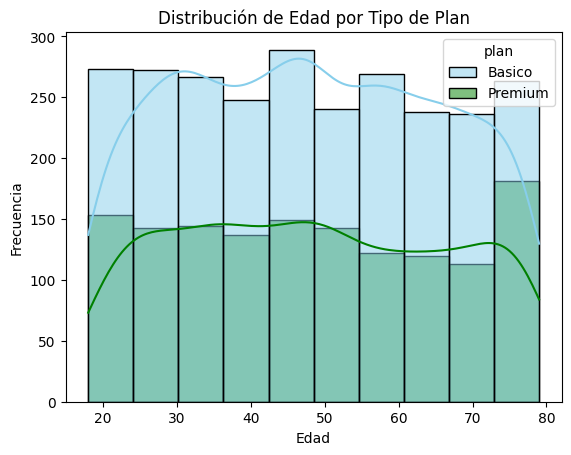

In [122]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', bins=10, hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La distribución simetrica en los dos tipos de plan con un leve sesgo a la izquierda que indica que las personas entre 70 y 80 años son los principales clientes del paln Premium. Sin embargo no es un sesgo lo suficientemente marcado por lo que en general el tipo de plan que adquiere cada persona no depende estrechamente con la edad.

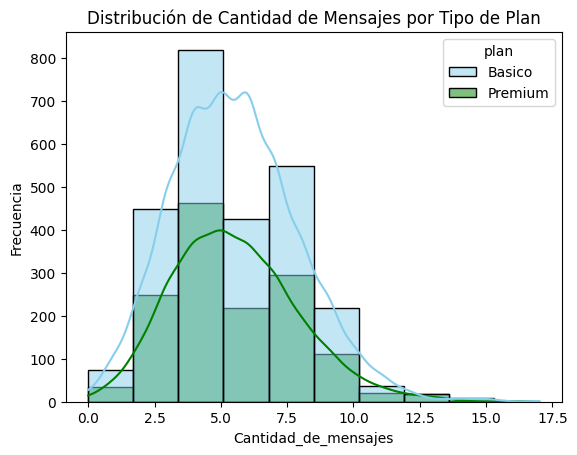

In [123]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', bins=10, hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de Cantidad de Mensajes por Tipo de Plan')
plt.xlabel('Cantidad_de_mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La distribución presenta sesgo a la derecha lo cual indica que la mayoria de los cientes se mantiene en una catidad de mensajes baja por mes, alrededor de 5 mensajes, sin embargo hay algunos usuarios que envian hasta 17 lo cual es perfectamente normal pero no representa el comportamiento general de las personas en ninguno de los dos tipos de plan.

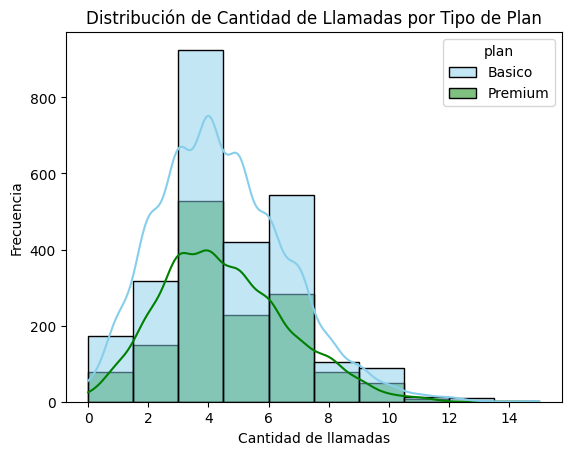

In [124]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', bins=10, hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La distribución es sesgada a la derecha lo cual presenta una distribución muy similar a los mensajes: la mayoría de usuarios realizan una cantidad baja de llamadas, alrededor de 4, pero existen algunos que llegan a realizar hasta 14 llamadas o más por mes que sigue siendo una cantidad muy plausible 

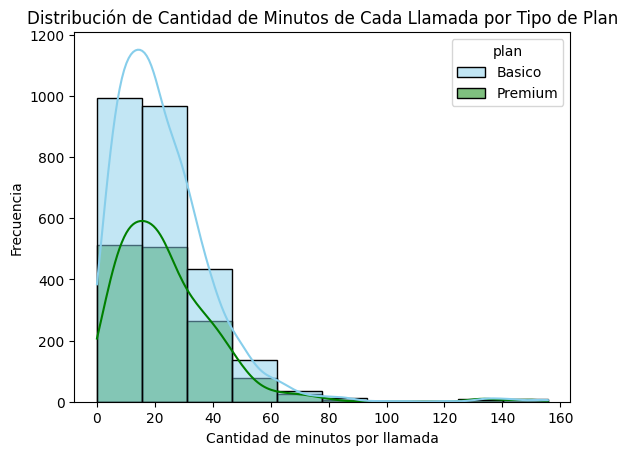

In [125]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', bins=10, hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de Cantidad de Minutos de Cada Llamada por Tipo de Plan')
plt.xlabel('Cantidad de minutos por llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La distribución es muy sesgada a la derecha lo cual en un primer momento despierta la atención del análisis, sin embargo, esto nos indica que la mayor parte de las llamadas dura máximo 30 minutos pero existen algunos usuarios que pueden llegar a durar más de 140 minutos por llamada lo cual a pesar de ser varias veces el promedio sigue siendo totalmente posible.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

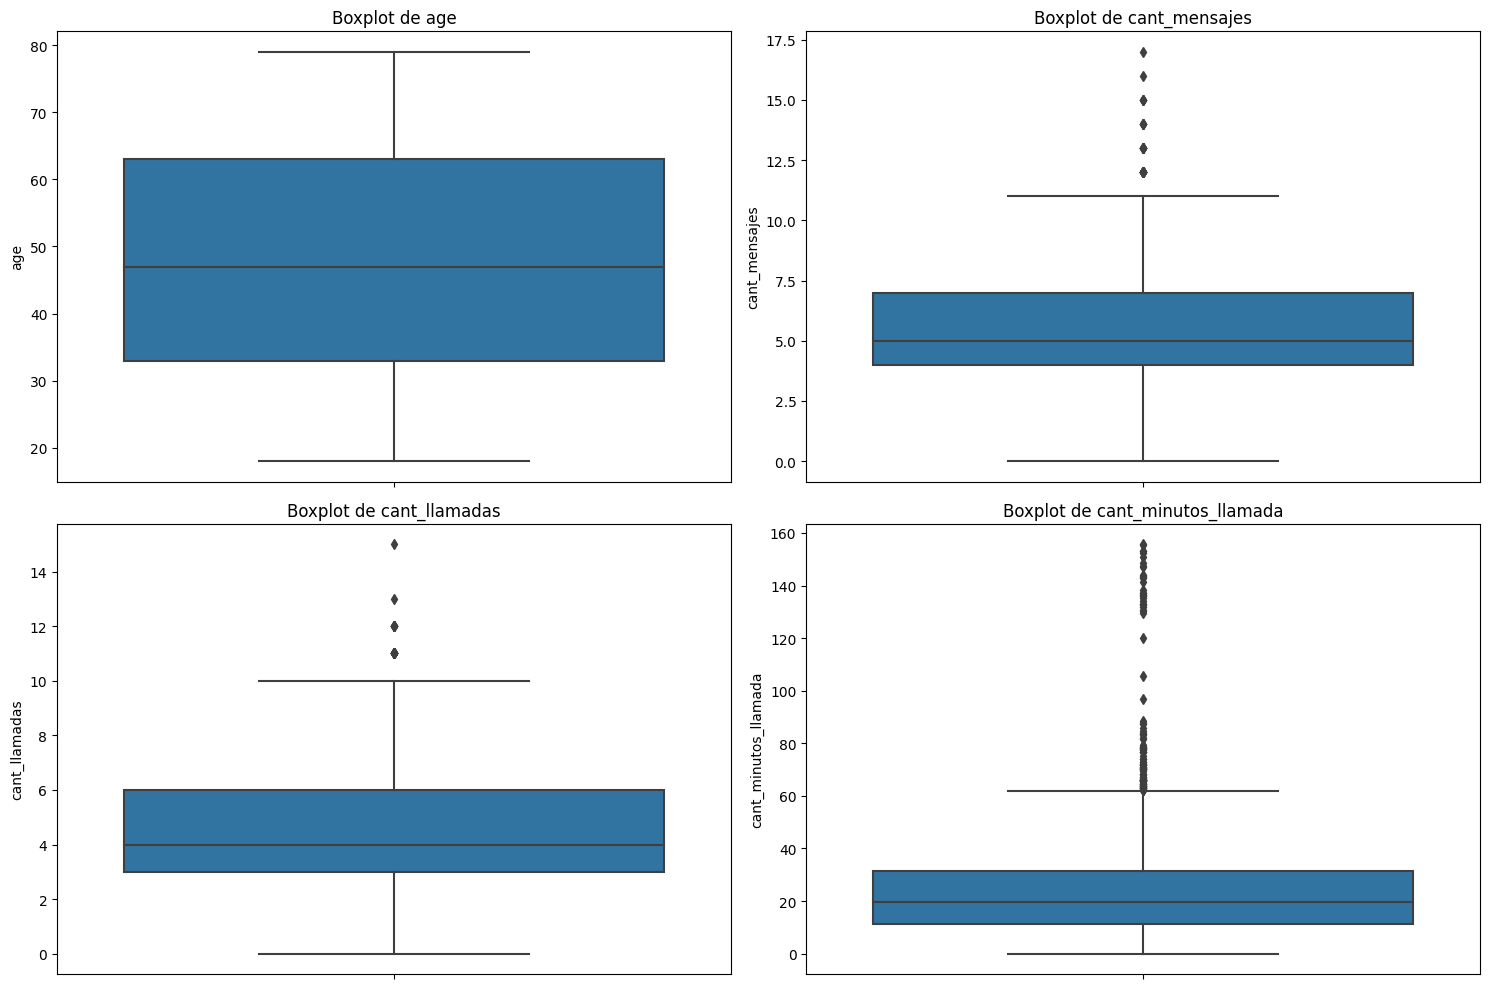

In [126]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

plt.figure(figsize=(15, 10))

for i, columna in enumerate(columnas_numericas, 1):
    plt.subplot(2, 2, i)  
    sns.boxplot(data=user_profile, y=columna)
    plt.title(f'Boxplot de {columna}')
    plt.ylabel(columna)

plt.tight_layout()
plt.show()

💡Insights: 
- Age: no outliers
- cant_mensajes: presenta outliers respecto a los rangos intercuartilicos, sin embargo, los valores permiten mantenerlos sin afectar la información
- cant_llamadas: presenta outliers de una forma muy similar a la cantidad de mensajes por lo que se recomienda la misma acción: mantenerlos ya que no distorcionan la información
- cant_minutos_llamada: presenta unos outliers mucho más altos llegando a superar varias veces los valores dentro del Q3 y el Q4, no obstante, dado el contexto donde una persona puede realizar llamadas de un par de horas se pueden mantener los valores teniendolos en cuenta para el análisis evitando usar promedios y haciendo uso de la media para evitar promedios inflados por estos otuliers

In [127]:
# Calcular límites con el método IQR
columnas_limites = ['cant_minutos_llamada']

for columna in columnas_limites:
    # Calcular Q1 (percentil 25) y Q3 (percentil 75)
    Q1 = user_profile[columna].quantile(0.25)  # ← Cambié por 'columna'
    Q3 = user_profile[columna].quantile(0.75)  # ← Cambié por 'columna'
    
    # Calcular IQR (Rango Intercuartílico)
    IQR = Q3 - Q1
    
    # Calcular límites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    print(f"\n--- {columna} ---")  # ← Cambié por 'columna'
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Límite inferior: {limite_inferior}")
    print(f"Límite superior: {limite_superior}")
    
    # Contar outliers
    outliers = user_profile[(user_profile[columna] < limite_inferior) | 
                           (user_profile[columna] > limite_superior)]
    print(f"Cantidad de outliers: {len(outliers)}")




--- cant_minutos_llamada ---
Q1: 11.12
Q3: 31.415
IQR: 20.295
Límite inferior: -19.322500000000005
Límite superior: 61.8575
Cantidad de outliers: 109


In [128]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile['cant_minutos_llamada'].describe()

count    3999.000000
mean       23.317054
std        18.168095
min         0.000000
25%        11.120000
50%        19.780000
75%        31.415000
max       155.690000
Name: cant_minutos_llamada, dtype: float64

💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- Mantener, en valores absolutos y bajo el contexto de la compañia los outliers son totalmente posibles
- cant_llamadas: mantener o no outliers, porqué?
- Mantener, al igual que los mensajes la cantidad de llamadas maximas por usuario se mantiene dentro de un rango razonable sin afectar los datos
- cant_minutos_llamada: mantener o no outliers, porqué?
- Mantener, si bien los outliers en esta medición son mucho más fuertes al tener en cuenta el contexto de la compañia, la cantidad maxima de minutos por llamada sigue siendo algo razonable. 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [129]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 
    'Bajo uso', 
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10), 
        'Uso medio', 
        'Alto uso'
    )
)

In [130]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,Medellín,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [131]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    (user_profile['age'] < 30),
    'Joven', 
    np.where(
        (user_profile['age'] < 60), 
        'Adulto', 
        'Adulto mayor'
    )
)

In [132]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,Medellín,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

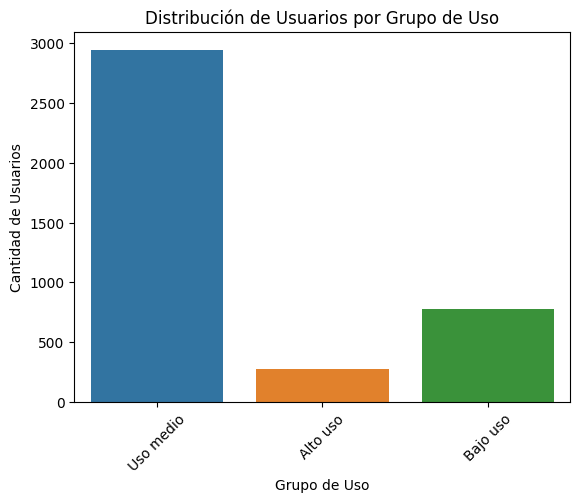

In [133]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.xticks(rotation=45)
plt.show()

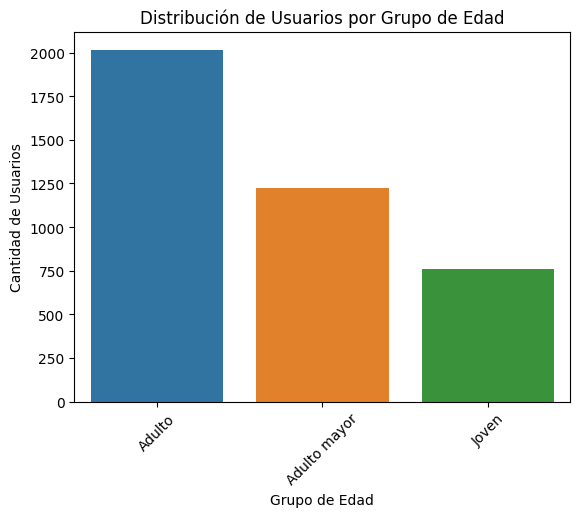

In [134]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.xticks(rotation=45)
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
 

 

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
 - El df 'plan' no presentaba errores
 - El df 'users' presentaba principalmente dos problemas: registros nulos en 'city'(12.05%) y números negativos en 'age'. Los valores nulos en 'city' se imputaron, mientras las edades negativas en 'age' fueron remplazadas por la media de edad. Así mismo se encontró un 88.35% de datos nulos en 'churn_date' lo cual es normal ya que indica que la gran mayoría de usuarios seguian activos al momento de reportar los datos.
 - El df 'usage' se detectaron un alto porcentaje de datos nulos en las columnas de 'duration' y 'length' para posteriormente comprobar que eran causados por el tipo de registro (llamada o mensaje de texto), ya que una llamada no tiene una cantidad o longitud de caracteres mientras un mensaje no tiene una duración en tiempo lo cual estaba generando estos nulos. También se encontro menos de 1% de valores nulos en 'date' pero se decide mantener los datos por el bajo impacto frente al grueso de la información.
   

🔍 **Segmentos por Edad**
¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

 - Se identicaron 3 segmentos: joven, adulto y adulto mayor.
 - Se realizo un análisis para determinar si la edad era un factor para elegir el tipo de plan pero el resultado es que este no es un valor determinante, con un leve sesgo de preferencia por el plan 'Premium' por los usuarios entre 70 y 80 años.


📊 **Segmentos por Nivel de Uso**

 - En cuanto al uso la gran mayoría de usuarios presento un uso similar, aunque se detectaron outliers en la cantidad de llamadas, mensajes y en especial de minutos por llamada se concluyo que todos los datos bajo el contexto de la compañia eran plausibles.
 - Así mismo no de detecto una correlación clara entre el grupo de edad y el uso, tampoco por tipo de plan. Es decir, que el uso para los clientes en general independiente del tipo de plan o grupo de edad es muy homogeneo tendiendo a valores bajos en mensajes entre 5 a 8 y en llamdas entre 6 y 10 con una duración de entre 20 a 31 minutos. En todas las medidas se encontraton outliers, sin embargo, se determina que todos los datos se encontraban en un rango razonable por lo que se pueden mantener.  

➡️ Esto sugiere que la edad no es es un factor determinante para elegir el tipo de plan de cada cliente, así como el hecho de que la edad tampoco es un factor que determine un mayor o menor uso.


💡 **Recomendaciones**
- Si bien se concluyó que la edad no es un factor determinante, si se encontró una leve tendencia en las personas entre 70 y 80 años por el plan 'Premium' lo cual se puede utilizar para crear campañas enfocadas en este segmento tanto a los cliente que ya tienen un plan básico, para que realicen un up grade al plan 'Premium' como para los nuevos clientes que la compañia tenga.
- También en cuanto al uso la gran mayoría de usuarios independientemente de su plan mantuvieron un uso relativamente bajo, por lo cual se puede utilizar una apliación de minutos y gigas como gancho para nuevos clientes o up sells de los usuarios con plane 'Básico' sin producir una subida agrsiva en el consumo de los servicios que afecte a la compañia. 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`